# Write Report
Discuss feature extraction power of your favorite CNN pretrained by ImageNet datset before and after transfer learning by MNIST didgit dataset by plotting high dimensional feature vectors on 2D plane using three dimension reduction techniques.

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap


# Load the Dataset

In [15]:
(x_train, y_train), _ = mnist.load_data()

sample_size = 2000
x_sample = x_train[:sample_size]
y_sample = y_train[:sample_size]

x_sample = tf.image.resize_with_pad(tf.expand_dims(x_sample, -1), 224, 224)
x_sample = tf.image.grayscale_to_rgb(x_sample) / 255.0
y_sample_cat = to_categorical(y_sample, 10)



# Load Pretrained DenseNet121

In [ ]:
base_model = DenseNet121(include_top=False, input_shape=(224,224,3), weights='imagenet')

x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(10, activation='softmax')(x)
feature_extractor = Model(inputs=base_model.input, outputs=output)


# Extract Features (Before Transfer Learning)

In [25]:
features_before = feature_extractor.predict(x_sample, verbose=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step


# Fine-Tune DenseNet121 on MNIST (Transfer Learning)

In [18]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(10, activation='softmax')(x)
model_tuned = Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers[:-6]:
    layer.trainable = True

model_tuned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_tuned.fit(x_sample, y_sample_cat, epochs=1, batch_size=32, verbose=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 628s 9s/step - accuracy: 0.7831 - loss: 0.6806


In [ ]:
x1 = base_model.output
x1 = GlobalAveragePooling2D()(x1)
output1 = Dense(10, activation='softmax')(x1)
model_tuned1 = Model(inputs=base_model.input, outputs=output1)

for layer in base_model.layers:
    layer.trainable = False
# model_tuned1.summary(show_trainable=True)

# Feature Extractor After Fine-Tuning

In [21]:
model_tuned_feat = Model(inputs=model_tuned.input, outputs=model_tuned.layers[-2].output)
features_after = model_tuned_feat.predict(x_sample, verbose=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step


In [22]:
def plot_dim_reduction(features, labels, method='pca', title=''):
    if method == 'pca':
        reducer = PCA(n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42)
    elif method == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=42)

    reduced = reducer.fit_transform(features)

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette='tab10', s=50, legend='full')
    plt.title(f"{title} ({method.upper()})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.tight_layout()
    plt.show()


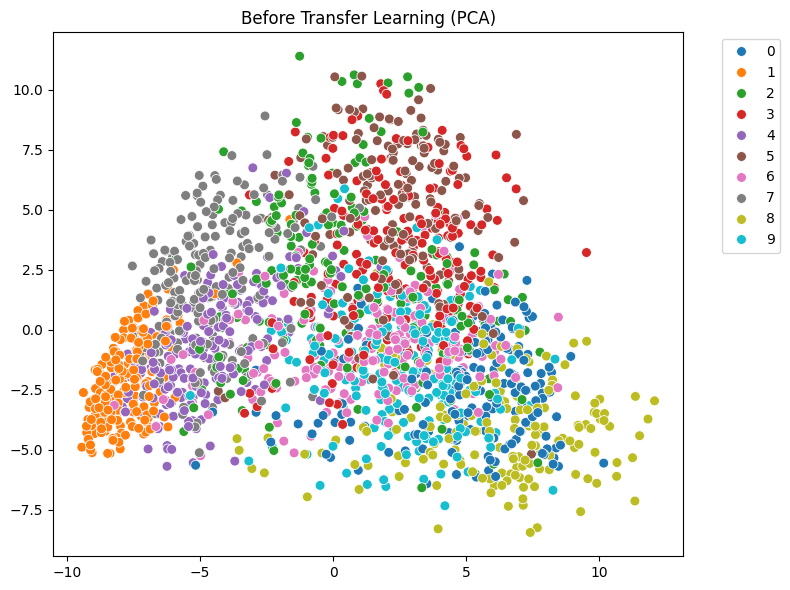

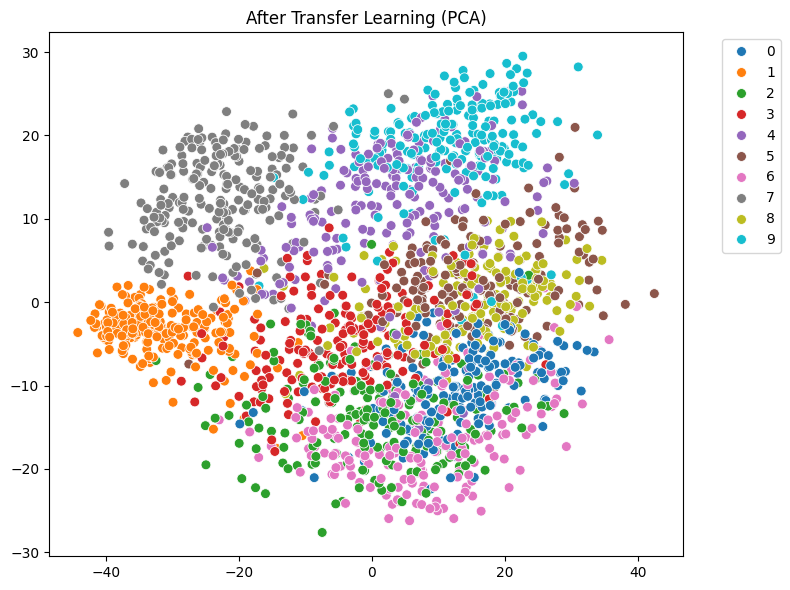

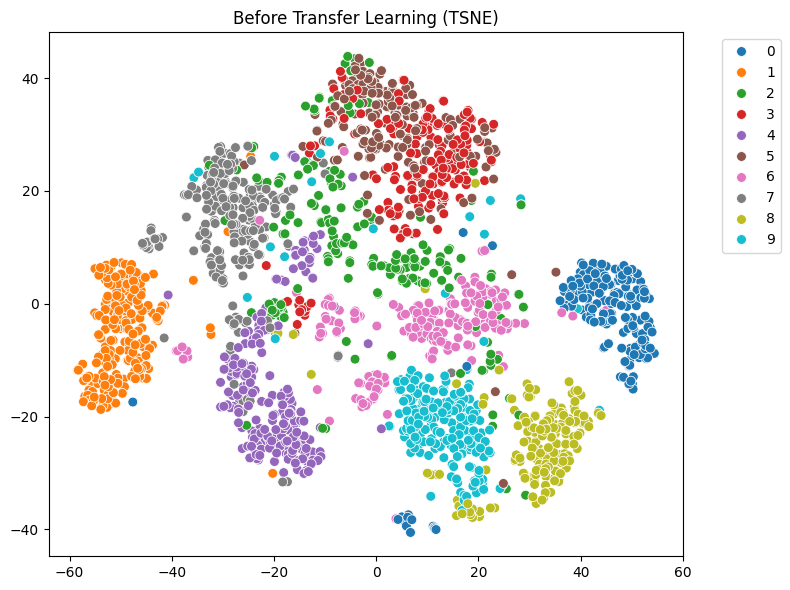

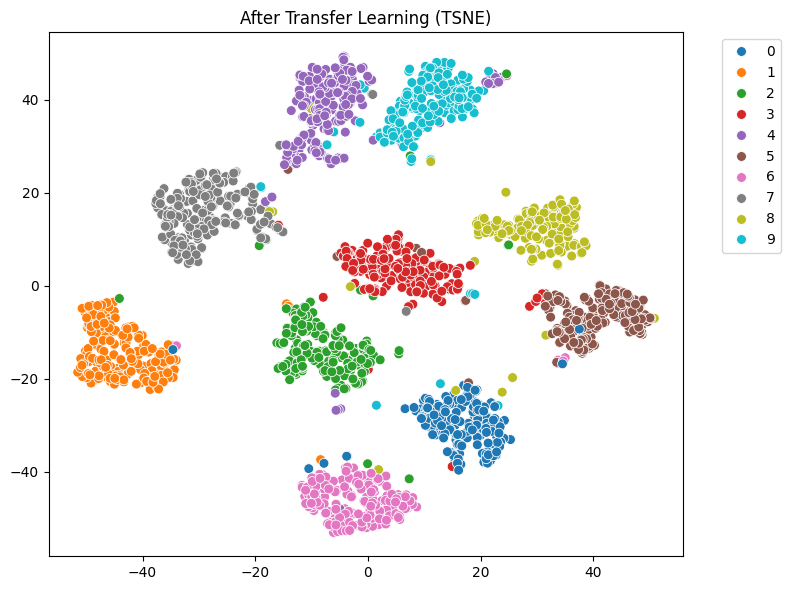

/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


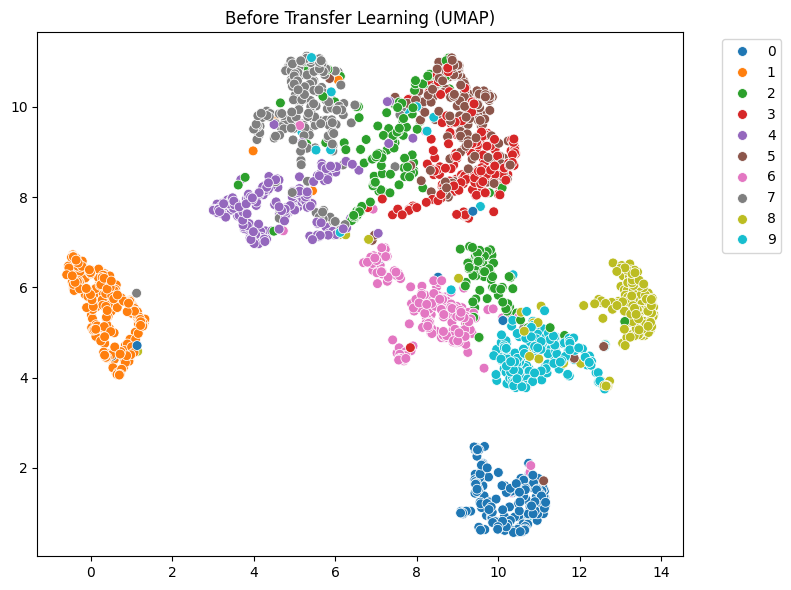

/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


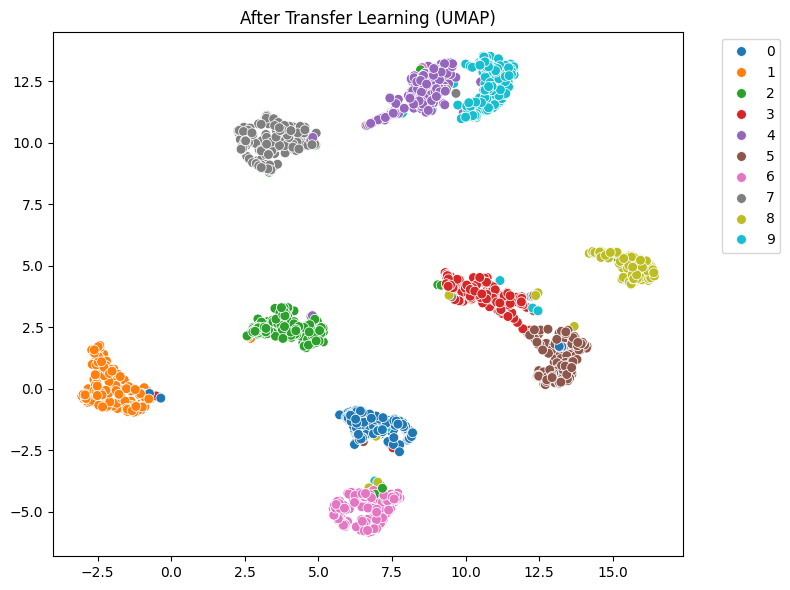

In [ ]:
for method in ['pca', 'tsne', 'umap']:
    plot_dim_reduction(features_before, y_sample, method, title="Before Transfer Learning")
    plot_dim_reduction(features_after, y_sample, method, title="After Transfer Learning")


In [26]:
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding
import umap
import matplotlib.pyplot as plt
import seaborn as sns

def plot_nonlinear_manifold_methods(features, labels, title='Nonlinear Manifold Learning'):
    methods = {
        't-SNE': TSNE(n_components=2, random_state=42),
        'UMAP': umap.UMAP(n_components=2, random_state=42),
        'Isomap': Isomap(n_components=2),
        'LLE': LocallyLinearEmbedding(n_components=2, random_state=42),
        'MDS': MDS(n_components=2, random_state=42),
        'Spectral': SpectralEmbedding(n_components=2, random_state=42)
    }

    plt.figure(figsize=(20, 10))  # 2 rows of 3 plots

    for i, (name, reducer) in enumerate(methods.items(), 1):
        try:
            reduced = reducer.fit_transform(features)
            plt.subplot(2, 3, i)
            sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette='tab10', s=40, legend=False)
            plt.title(f"{title} - {name}")
            plt.xlabel('Dim 1')
            plt.ylabel('Dim 2')
        except Exception as e:
            print(f"Error with {name}: {e}")

    plt.tight_layout()
    plt.show()
